In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load data
# for this analysis i will use reduced df that has variables chosen after Shap analysis
df = pd.read_csv("mushroom_reduced.csv")

df

,class,does-bruise-or-bleed,stem-height,stem-width,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,...,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y
0,1,0,16.95,17.09,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,17.99,18.19,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,1,0,17.80,17.74,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1,0,15.77,15.98,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1,0,16.53,17.20,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,1,0,3.93,6.22,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
61065,1,0,3.18,5.43,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
61066,1,0,3.86,6.37,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
61067,1,0,3.56,5.44,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## NEW COMPARISON ## - stem-width vs class


<Figure size 1000x600 with 0 Axes>

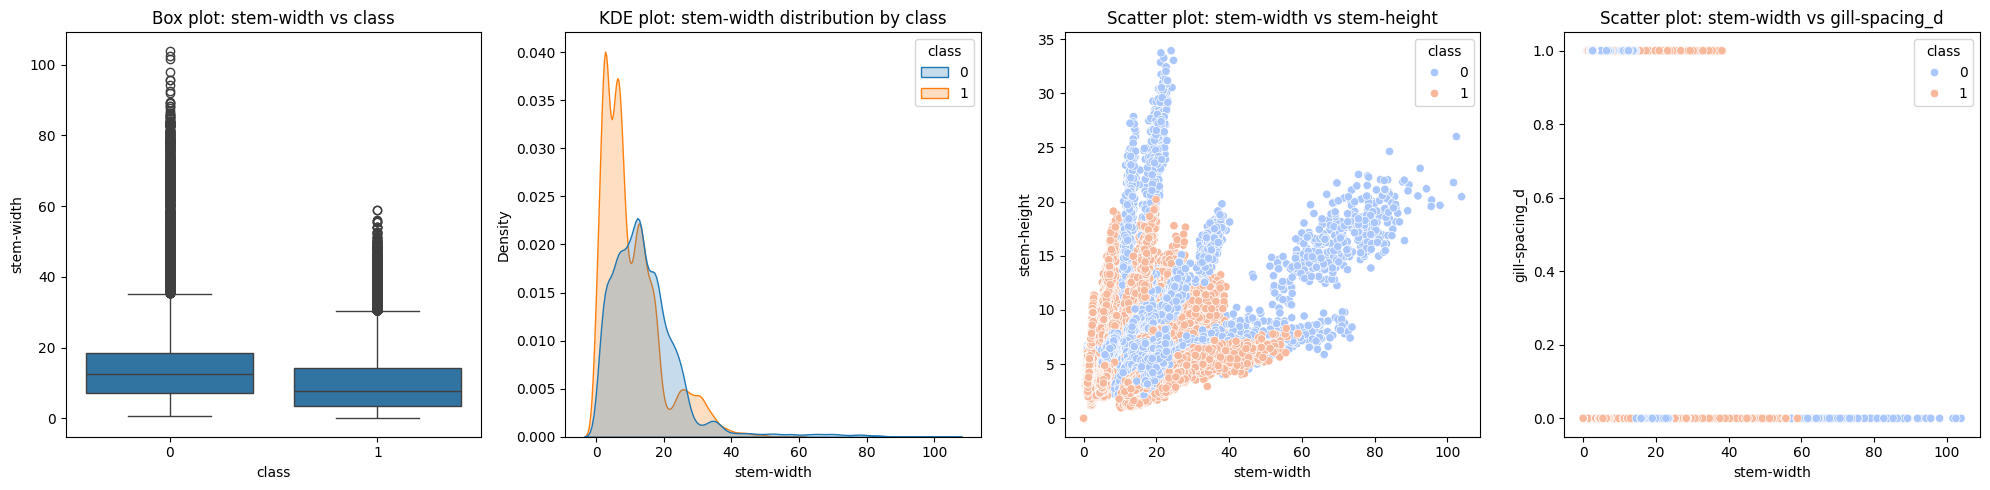

## NEW COMPARISON ## - stem-height vs class


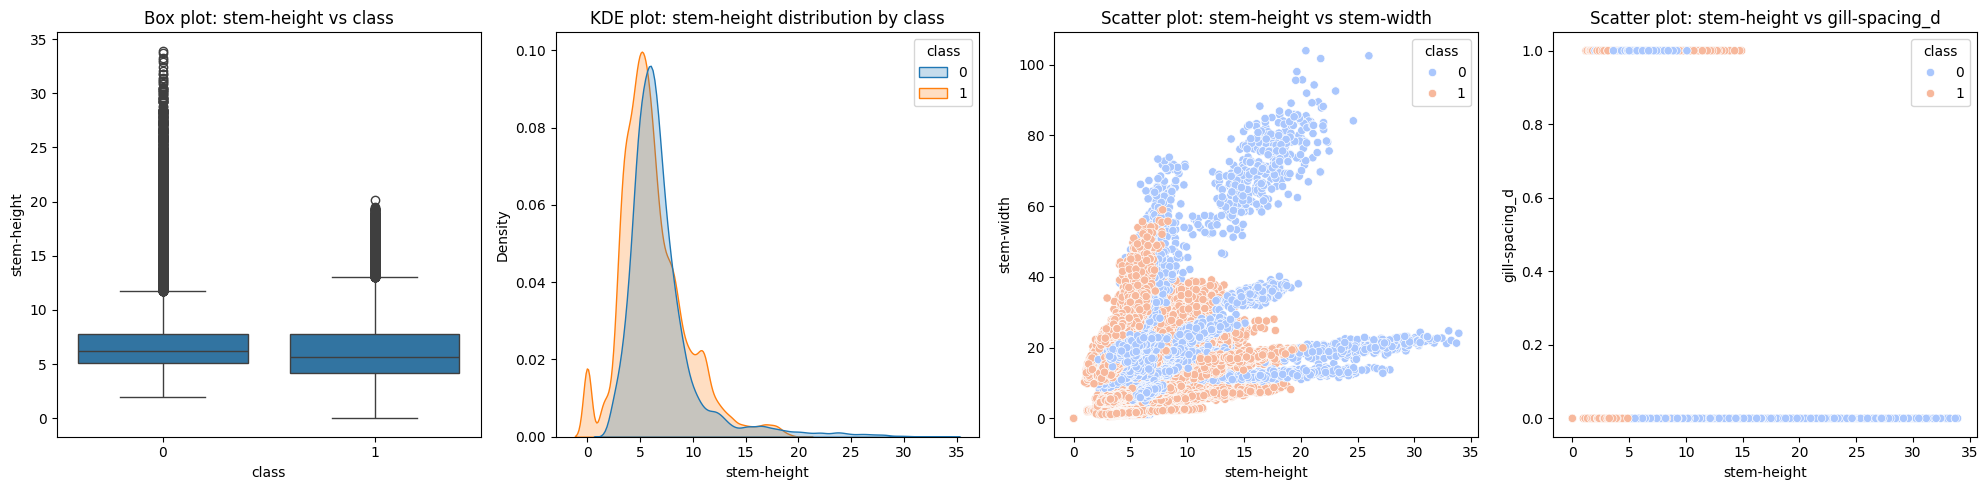

## NEW COMPARISON ## - gill-spacing_d vs class


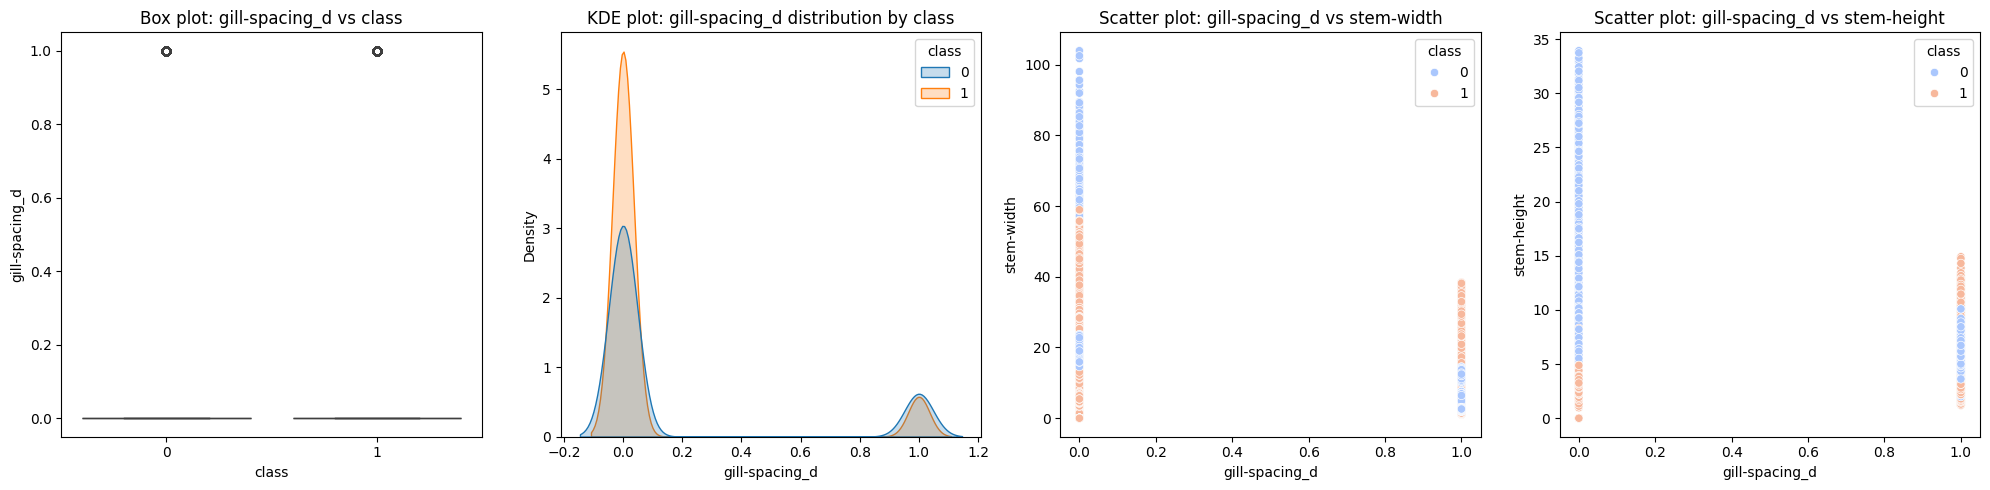

In [3]:
# CODE PARTIALLY GENERATED BY CHATGPT
# modified by instructor to have more features and small finetuning for presentation

# List of suspected columns for overlap
# USE SHAP, LIME, phik-matrix, correlation matrix etc to find columns that seems
# probable for having overlap, noise, redundancy, distribution problems and/or outlier problems
# try to keep the amount of variables to a small number at a time, so you don't slow down the
# process of plot generation below
suspected_columns = ['stem-width', 'stem-height', 'gill-spacing_d']
target_variable = 'class'  # The target variable

# Plot size settings
plt.figure(figsize=(10, 6))

# Iterate through suspected columns to generate box plots and scatter plots in a horizontal layout
for feature in suspected_columns:
    print(f"## NEW COMPARISON ## - {feature} vs {target_variable}")
    num_other_features = len([col for col in suspected_columns if col != feature])
    
    # Create a horizontal grid with 1 row and (1 + num_other_features + 1) columns
    fig, axes = plt.subplots(1, 2 + num_other_features, figsize=(5 * (2 + num_other_features), 5))
    
    # First plot: Box plot for the feature against the target variable
    sns.boxplot(x=target_variable, y=feature, data=df, ax=axes[0])
    axes[0].set_title(f'Box plot: {feature} vs {target_variable}')
    
    # Second plot: KDE plot for the feature, showing distribution by target variable
    sns.kdeplot(x=feature, hue=target_variable, data=df, fill=True, ax=axes[1])
    axes[1].set_title(f'KDE plot: {feature} distribution by {target_variable}')
    
    # Remaining plots: Scatter plots for the feature against every other feature
    for i, other_feature in enumerate([col for col in suspected_columns if col != feature]):
        sns.scatterplot(x=feature, palette="coolwarm", y=other_feature, hue=target_variable, data=df, ax=axes[i + 2])
        axes[i + 2].set_title(f'Scatter plot: {feature} vs {other_feature}')
    
    # Display the entire row of plots
    plt.tight_layout()
    plt.show()

In [4]:
df.columns

Index(['class', 'does-bruise-or-bleed', 'stem-height', 'stem-width',
       'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h',
       'cap-surface_i', 'cap-surface_k', 'cap-surface_l',
       'cap-surface_missing', 'cap-surface_s', 'cap-surface_t',
       'cap-surface_w', 'cap-surface_y', 'gill-attachment_a',
       'gill-attachment_d', 'gill-attachment_e', 'gill-attachment_f',
       'gill-attachment_missing', 'gill-attachment_p', 'gill-attachment_s',
       'gill-attachment_x', 'gill-spacing_c', 'gill-spacing_d',
       'gill-spacing_f', 'gill-spacing_missing', 'gill-color_b',
       'gill-color_e', 'gill-color_f', 'gill-color_g', 'gill-color_k',
       'gill-color_n', 'gill-color_o', 'gill-color_p', 'gill-color_r',
       'gill-color_u', 'gill-color_w', 'gill-color_y', 'stem-color_b',
       'stem-color_e', 'stem-color_f', 'stem-color_g', 'stem-color_k',
       'stem-color_l', 'stem-color_n', 'stem-color_o', 'stem-color_p',
       'stem-color_r', 'stem-color_u', 'st

<Axes: xlabel='stem-width', ylabel='stem-height'>

c:\Storage\Studies\Lapland_AMK\5_semester\Advanced Data Analytics\venv312\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Storage\Studies\Lapland_AMK\5_semester\Advanced Data Analytics\venv312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


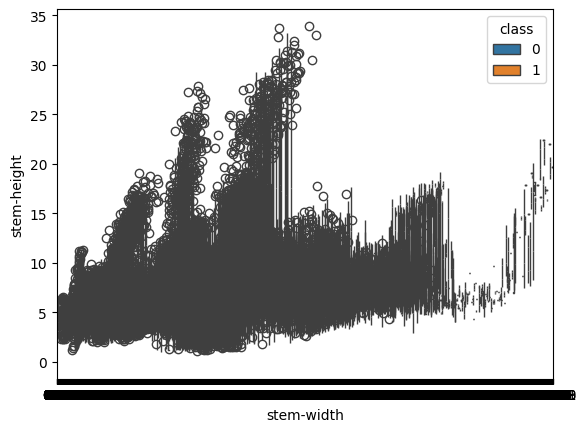

In [ ]:
# on this plot it is difficult to understand anything
sns.boxplot(x="stem-width", y="stem-height", data=df, hue="class")

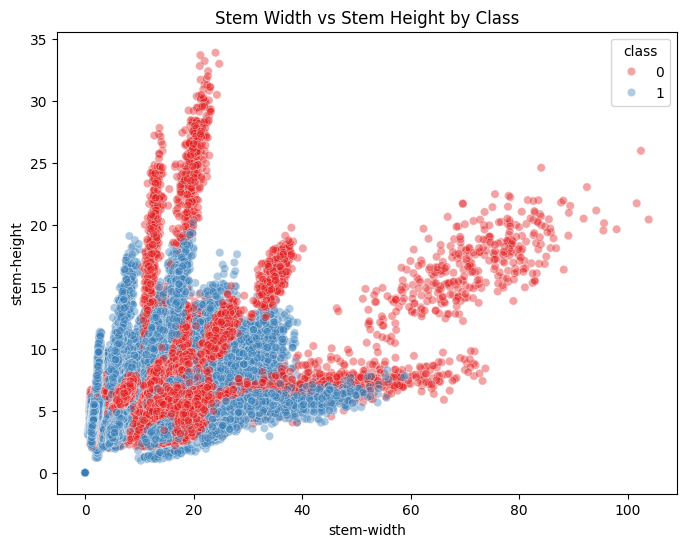

In [ ]:
# added alpha=0.4 that makes overlapping points transparent (with help of chatgpt)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="stem-width",
    y="stem-height",
    hue="class",
    alpha=0.4,        # transparency
    palette="Set1"
)

plt.title("Stem Width vs Stem Height by Class")
plt.show()